In [3]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [4]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.features.tfidf import TFIDFVectorizer
from src.preprocessing.cleaner import preprocess_for_tfidf

In [ ]:
tfidf = TFIDFVectorizer.load("../artifacts/vectorizers/tfidf.joblib")

In [6]:
print(f"Number of Features: {tfidf.feature_count:,}")

Number of Features: 50,000


In [7]:
feature_names = tfidf.feature_names

In [8]:
pd.Series(feature_names[:30])

0              00
1           00 00
2          00 and
3          00 for
4             000
5              01
6              02
7              03
8              04
9              05
10             06
11             07
12             08
13             09
14           0ghz
15             10
16          10 00
17         10 000
18          10 10
19         10 100
20          10 11
21          10 12
22          10 15
23          10 20
24         10 and
25          10 as
26       10 bucks
27         10 but
28    10 computer
29        10 days
dtype: str

In [9]:
pd.Series(feature_names[-30:])

0              zipped
1              zipper
2          zipper and
3           zipper is
4           zipper on
5       zipper pocket
6            zippered
7     zippered pocket
8             zippers
9         zippers and
10        zippers are
11               zips
12              zmodo
13               zone
14              zones
15               zoom
16           zoom and
17            zoom in
18            zoom is
19          zoom lens
20         zoom range
21           zoom the
22             zoomed
23          zoomed in
24            zooming
25              zooms
26               zosi
27              zotac
28               zvox
29              zyxel
dtype: str

In [10]:
unigrams = [w for w in feature_names if " " not in w]

len(unigrams)

9378

In [11]:
bigrams = [w for w in feature_names if " " in w]

len(bigrams)

40622

In [12]:
pd.Series(bigrams[:50])

0           00 00
1          00 and
2          00 for
3           10 00
4          10 000
5           10 10
6          10 100
7           10 11
8           10 12
9           10 15
10          10 20
11         10 and
12          10 as
13       10 bucks
14         10 but
15    10 computer
16        10 days
17     10 degrees
18        10 feet
19        10 foot
20         10 for
21          10 ft
22        10 home
23       10 hours
24          10 in
25        10 inch
26      10 inches
27          10 is
28          10 it
29         10 key
30      10 laptop
31     10 machine
32       10 miles
33         10 min
34     10 minutes
35       10 month
36      10 months
37        10 more
38          10 of
39          10 on
40          10 or
41          10 pc
42         10 pro
43     10 seconds
44          10 so
45       10 stars
46      10 tablet
47        10 that
48         10 the
49        10 this
dtype: str

In [13]:
np.random.seed(42)

random_features = np.random.choice(
    feature_names,
    size=50,
    replace=False,
)

pd.Series(random_features)

0          refurbished
1        comparing the
2                 15mm
3              each of
4              that we
5     this transmitter
6        defective one
7            yes below
8             are must
9             sorry to
10            time try
11             take an
12           better it
13          again only
14               hoods
15           or gaming
16          for review
17              rocket
18             easy to
19         drastically
20            best but
21             gb card
22            about on
23              for on
24       experience to
25         network and
26           they need
27             pair so
28       speakers with
29        realized how
30              so got
31           marketing
32                  bd
33          applicable
34          swapped it
35             it long
36          you switch
37              thingy
38      when inserting
39             detects
40           the weird
41       keyboards but
42        compare them
43         

In [14]:
len(feature_names)

50000

In [15]:
keywords = [
    "good",
    "bad",
    "great",
    "excellent",
    "love",
    "not good",
    "highly recommend",
    "waste money",
]
for word in keywords:
    print(
        word,
        word in feature_names,
    )

good True
bad True
great True
excellent True
love True
not good True
highly recommend True
waste money False


In [16]:
train_df = pd.read_csv("../data/interim/train_split.csv")

train_df["clean_text"] = train_df["reviewText"].apply(preprocess_for_tfidf)

X_train = tfidf.transform(train_df["clean_text"])

C:\Users\fam-01\AppData\Local\Temp\ipykernel_21940\3950728274.py:1: DtypeWarning: Columns (0: vote) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv("../../data/interim/train_split.csv")


In [17]:
non_zero = X_train.getnnz(axis=1)

pd.Series(non_zero).describe()

count    671155.000000
mean        132.739181
std         106.921500
min           0.000000
25%          70.000000
50%          98.000000
75%         154.000000
max        2715.000000
dtype: float64

In [20]:
zero_docs = (non_zero == 0).sum()

print(f"Documents with zero active features: {zero_docs}")

Documents with zero active features: 9


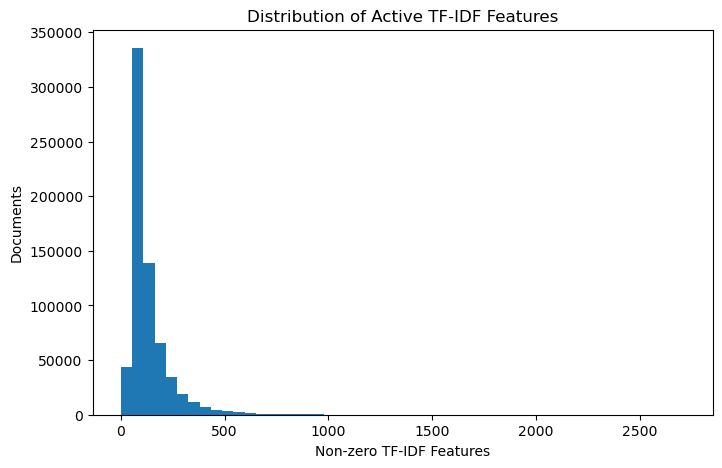

In [18]:
plt.figure(figsize=(8, 5))

plt.hist(
    non_zero,
    bins=50,
)

plt.xlabel("Non-zero TF-IDF Features")

plt.ylabel("Documents")

plt.title("Distribution of Active TF-IDF Features")

plt.show()

* TF-IDF successfully generated 50,000 features.
* Both unigram and bigram features are present.
* Common sentiment expressions such as "highly recommend" and "not worth" are included in the vocabulary.
* The feature matrix is sparse, making it suitable for linear machine learning models.

The TF-IDF representation is sparse, contains both unigram and bigram features, captures common sentiment expressions, and is suitable for training linear machine learning models.